In [65]:
%matplotlib inline
import os, re, html, warnings
import numpy as np
import pandas as pd
import joblib
import matplotlib
import matplotlib.pyplot as plt
from scipy.sparse import hstack, csr_matrix, save_npz
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import MinMaxScaler

In [66]:
import time
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support, roc_auc_score, classification_report, ConfusionMatrixDisplay)

In [67]:
DATA_PATH = "datasets/IMDB Dataset.csv"
OUT_DIR = "artifacts"
PLOT_DIR = "eda_plots"
SEED = 42
TEST_SIZE = 0.2
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)

def section(title):
    print("\n" + "=" * 80 + f"\n{title}\n" + "=" * 80)

In [68]:
df = pd.read_csv(DATA_PATH)
print(f"Loaded {df.shape[0]:,} rows x {df.shape[1]} columns from '{DATA_PATH}'")

Loaded 50,000 rows x 2 columns from 'datasets/IMDB Dataset.csv'


In [69]:
print(df.head(3).to_string(max_colwidth=100))
print("\nDtypes:\n", df.dtypes)
print("\nMissing values per column:\n", df.isna().sum())
print(f"\nExact duplicate rows      : {df.duplicated().sum():,}")
print(f"Duplicate review texts    : {df['review'].duplicated().sum():,}")
print("\nClass distribution:\n", df["sentiment"].value_counts())
print("Unique label values:", df["sentiment"].unique())

                                                                                                review sentiment
0  One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked....  positive
1  A wonderful little production. <br /><br />The filming technique is very unassuming- very old-ti...  positive
2  I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air...  positive

Dtypes:
 review       str
sentiment    str
dtype: object

Missing values per column:
 review       0
sentiment    0
dtype: int64

Exact duplicate rows      : 418
Duplicate review texts    : 418

Class distribution:
 sentiment
positive    25000
negative    25000
Name: count, dtype: int64
Unique label values: <StringArray>
['positive', 'negative']
Length: 2, dtype: str


In [70]:
df["_raw_words"] = df["review"].astype(str).str.split().str.len()
df["_raw_chars"] = df["review"].astype(str).str.len()
print("\nReview length (words) by class:")
print(df.groupby("sentiment")["_raw_words"].describe().round(1))
html_share = df["review"].astype(str).str.contains(r"<[^>]+>").mean()
print(f"\nReviews containing HTML tags: {html_share:.1%}")


Review length (words) by class:
             count   mean    std   min    25%    50%    75%     max
sentiment                                                          
negative   25000.0  229.5  164.9   4.0  128.0  174.0  278.0  1522.0
positive   25000.0  232.8  177.5  10.0  125.0  172.0  284.0  2470.0

Reviews containing HTML tags: 58.4%


In [71]:
q1, q3 = df["_raw_words"].quantile([0.25, 0.75])
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr
n_out = (df["_raw_words"] > upper_fence).sum()
print(f"Length outliers (> {upper_fence:.0f} words, IQR rule): {n_out:,} ({n_out/len(df):.1%})")


Length outliers (> 511 words, IQR rule): 3,708 (7.4%)


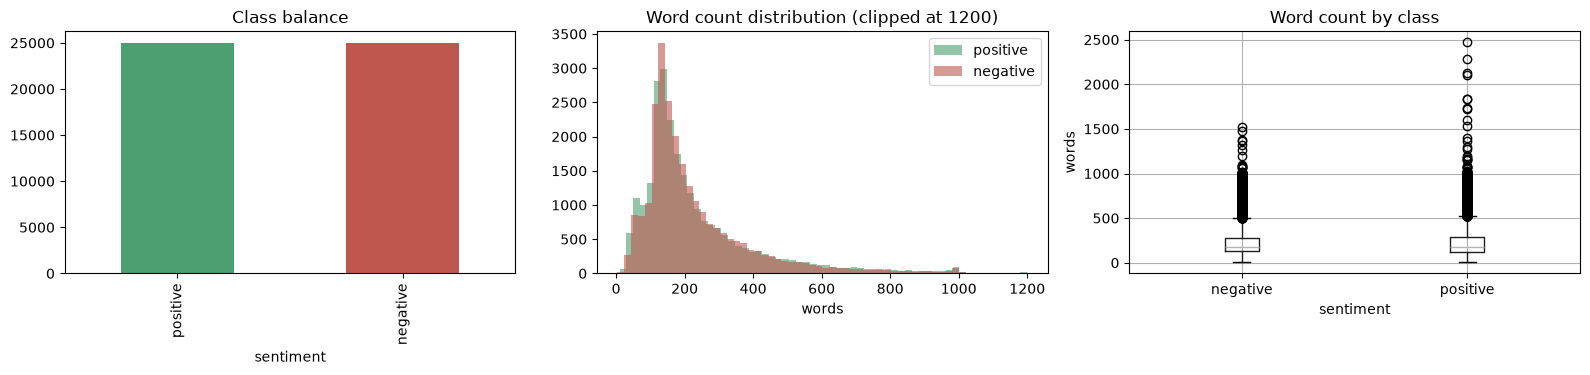

In [75]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
df["sentiment"].value_counts().plot.bar(ax=ax[0], color=["#4c9f70", "#c0574f"], title="Class balance")
for lab, c in [("positive", "#4c9f70"), ("negative", "#c0574f")]:
    ax[1].hist(df.loc[df["sentiment"] == lab, "_raw_words"].clip(upper=1200), bins=60, alpha=0.6, label=lab, color=c)
ax[1].set(title="Word count distribution (clipped at 1200)", xlabel="words"); ax[1].legend()
df.boxplot(column="_raw_words", by="sentiment", ax=ax[2], showfliers=True)
ax[2].set(title="Word count by class", ylabel="words"); plt.suptitle("")
plt.tight_layout(); plt.show()

In [76]:
for lab in ["positive", "negative"]:
    cv = CountVectorizer(stop_words="english", max_features=15)
    cv.fit(df.loc[df["sentiment"] == lab, "review"].str.replace(r"<[^>]+>", " ", regex=True).sample(5000, random_state=SEED))
    print(f"Top tokens ({lab}):", list(cv.get_feature_names_out()))

Top tokens (positive): ['best', 'film', 'films', 'good', 'great', 'just', 'life', 'like', 'love', 'movie', 'people', 'really', 'story', 'time', 'way']
Top tokens (negative): ['acting', 'bad', 'don', 'film', 'good', 'just', 'like', 'make', 'movie', 'movies', 'people', 'plot', 'really', 'story', 'time']


In [77]:
df = df.drop(columns=["_raw_words", "_raw_chars"])
n0 = len(df)

In [78]:
df = df.dropna(subset=["review", "sentiment"])
df["review"] = df["review"].astype(str).str.strip()
df = df[df["review"] != ""]
print(f"Removed missing/empty rows: {n0 - len(df)}")

Removed missing/empty rows: 0


In [79]:
df["sentiment"] = df["sentiment"].astype(str).str.strip().str.lower()
label_map = {"negative": 0, "positive": 1}
bad = ~df["sentiment"].isin(label_map)
print(f"Rows with unrecognised labels removed: {bad.sum()}")
df = df[~bad].copy()
df["label"] = df["sentiment"].map(label_map).astype(int)

Rows with unrecognised labels removed: 0


In [80]:
conflict = df.groupby("review")["label"].transform("nunique") > 1
print(f"Rows with same text but conflicting labels removed: {conflict.sum()}")
df = df[~conflict]
before = len(df)
df = df.drop_duplicates(subset="review", keep="first").reset_index(drop=True)
print(f"Duplicate reviews removed: {before - len(df):,}")

Rows with same text but conflicting labels removed: 0
Duplicate reviews removed: 418


In [81]:
def clean_text(text: str) -> str:
    text = html.unescape(text)
    text = re.sub(r"<[^>]+>", " ", text)                  # HTML tags (<br />, etc.)
    text = re.sub(r"http\S+|www\.\S+", " ", text)         # URLs
    text = text.lower()
    text = re.sub(r"n't\b", "nt", text)                   # don't -> dont (keeps negation as one token)
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)            # sooooo -> soo
    text = re.sub(r"[^a-z0-9' ]", " ", text)              # strip punctuation/symbols
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [82]:
df["raw_review"] = df["review"]
df["clean_review"] = df["review"].map(clean_text)

In [83]:
empty = df["clean_review"].str.len() == 0
print(f"Reviews empty after cleaning removed: {empty.sum()}")
df = df[~empty].reset_index(drop=True)

Reviews empty after cleaning removed: 0


In [84]:
wc = df["clean_review"].str.split().str.len()
print(f"Word count after cleaning: min={wc.min()}, median={wc.median():.0f}, max={wc.max()}")
print(f"Final dataset: {len(df):,} rows (removed {n0 - len(df):,} in total)")

Word count after cleaning: min=6, median=173, max=2473
Final dataset: 49,582 rows (removed 418 in total)


In [85]:
NUM_FEATURES = ["n_words", "n_chars", "avg_word_len", "n_exclaim", "n_question",
                "upper_ratio", "n_html_tags", "lexical_diversity", "n_negations"]
LOG_FEATURES = ["n_words", "n_chars", "n_exclaim", "n_question", "n_html_tags", "n_negations"]

In [86]:
NEGATIONS = {"not", "no", "never", "nothing", "nobody", "nowhere", "neither", "nor", "cannot",
             "dont", "doesnt", "didnt", "isnt", "wasnt", "wont", "wouldnt", "couldnt", "shouldnt",
             "hardly", "barely"}

In [87]:
def extract_features(raw: pd.Series, clean: pd.Series) -> pd.DataFrame:
    """Reusable at inference time: same features for a single review typed into the GUI."""
    tokens = clean.str.split()
    n_words = tokens.str.len()
    f = pd.DataFrame(index=raw.index)
    f["n_words"] = n_words
    f["n_chars"] = clean.str.len()
    f["avg_word_len"] = f["n_chars"] / n_words.clip(lower=1)
    f["n_exclaim"] = raw.str.count("!")
    f["n_question"] = raw.str.count(r"\?")
    letters = raw.str.count(r"[A-Za-z]").clip(lower=1)
    f["upper_ratio"] = raw.str.count(r"[A-Z]") / letters
    f["n_html_tags"] = raw.str.count(r"<[^>]+>")
    f["lexical_diversity"] = tokens.map(lambda t: len(set(t)) / max(len(t), 1))
    f["n_negations"] = tokens.map(lambda t: sum(w in NEGATIONS for w in t))
    return f

feats = extract_features(df["raw_review"], df["clean_review"])

In [88]:
corr = feats.assign(label=df["label"]).corr()["label"].drop("label").round(3)
print("Correlation of each engineered feature with the label:\n", corr.to_string())
print("Note: correlations are expected to be weak; these features supplement the text, not replace it.")

Correlation of each engineered feature with the label:
 n_words              0.011
n_chars              0.018
avg_word_len         0.082
n_exclaim           -0.017
n_question          -0.171
upper_ratio          0.024
n_html_tags         -0.023
lexical_diversity   -0.034
n_negations         -0.174
Note: correlations are expected to be weak; these features supplement the text, not replace it.


In [89]:
idx_train, idx_test = train_test_split(df.index, test_size=TEST_SIZE, stratify=df["label"], random_state=SEED)
X_text_train, X_text_test = df.loc[idx_train, "clean_review"], df.loc[idx_test, "clean_review"]
F_train, F_test = feats.loc[idx_train].copy(), feats.loc[idx_test].copy()
y_train, y_test = df.loc[idx_train, "label"].values, df.loc[idx_test, "label"].values
print(f"Train: {len(idx_train):,} | Test: {len(idx_test):,} | "
      f"Train positive share: {y_train.mean():.3f} | Test positive share: {y_test.mean():.3f}")

Train: 39,665 | Test: 9,917 | Train positive share: 0.502 | Test positive share: 0.502


In [90]:
tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=5, max_df=0.95, max_features=100_000,
                        sublinear_tf=True, dtype=np.float32)
bow = CountVectorizer(ngram_range=(1, 2), min_df=5, max_df=0.95, max_features=100_000,
                      binary=True, dtype=np.float32)
Xtf_train, Xtf_test = tfidf.fit_transform(X_text_train), tfidf.transform(X_text_test)
Xbow_train, Xbow_test = bow.fit_transform(X_text_train), bow.transform(X_text_test)
print(f"TF-IDF (1-2 grams): {Xtf_train.shape[1]:,} features | sparsity {1 - Xtf_train.nnz / np.prod(Xtf_train.shape):.4%}")
print(f"Binary BoW (1-2 grams): {Xbow_train.shape[1]:,} features")

TF-IDF (1-2 grams): 100,000 features | sparsity 99.7423%
Binary BoW (1-2 grams): 100,000 features


In [91]:
print("Skewness before scaling:\n", F_train.skew().round(2).to_string())

Skewness before scaling:
 n_words               2.17
n_chars               2.19
avg_word_len          0.24
n_exclaim            29.46
n_question            5.40
upper_ratio           5.79
n_html_tags           2.93
lexical_diversity     0.08
n_negations           2.09


In [92]:
for c in LOG_FEATURES:
    F_train[c] = np.log1p(F_train[c]); F_test[c] = np.log1p(F_test[c])
lo, hi = F_train.quantile(0.01), F_train.quantile(0.99)
F_train = F_train.clip(lo, hi, axis=1)
F_test = F_test.clip(lo, hi, axis=1)
print("\nSkewness after log + winsorising:\n", F_train.skew().round(2).to_string())


Skewness after log + winsorising:
 n_words              0.20
n_chars              0.21
avg_word_len         0.16
n_exclaim            1.48
n_question           1.59
upper_ratio          1.50
n_html_tags          0.13
lexical_diversity    0.08
n_negations         -0.12


In [93]:
scaler = MinMaxScaler()
S_train = scaler.fit_transform(F_train[NUM_FEATURES])
S_test = np.clip(scaler.transform(F_test[NUM_FEATURES]), 0, 1)

In [94]:
X_train_tfidf_full = hstack([Xtf_train, csr_matrix(S_train, dtype=np.float32)]).tocsr()
X_test_tfidf_full = hstack([Xtf_test, csr_matrix(S_test, dtype=np.float32)]).tocsr()
print(f"TF-IDF + numeric matrix: train {X_train_tfidf_full.shape}, test {X_test_tfidf_full.shape}")


TF-IDF + numeric matrix: train (39665, 100009), test (9917, 100009)


In [95]:
save_npz(f"{OUT_DIR}/X_train_tfidf.npz", Xtf_train);            save_npz(f"{OUT_DIR}/X_test_tfidf.npz", Xtf_test)
save_npz(f"{OUT_DIR}/X_train_tfidf_num.npz", X_train_tfidf_full); save_npz(f"{OUT_DIR}/X_test_tfidf_num.npz", X_test_tfidf_full)
save_npz(f"{OUT_DIR}/X_train_bow.npz", Xbow_train);             save_npz(f"{OUT_DIR}/X_test_bow.npz", Xbow_test)
np.save(f"{OUT_DIR}/y_train.npy", y_train); np.save(f"{OUT_DIR}/y_test.npy", y_test)
np.save(f"{OUT_DIR}/S_train.npy", S_train); np.save(f"{OUT_DIR}/S_test.npy", S_test)

In [96]:
df.loc[idx_train, ["raw_review", "clean_review", "label"]].to_csv(f"{OUT_DIR}/train_clean.csv", index=False)
df.loc[idx_test, ["raw_review", "clean_review", "label"]].to_csv(f"{OUT_DIR}/test_clean.csv", index=False)

In [97]:
joblib.dump(tfidf, f"{OUT_DIR}/tfidf_vectorizer.joblib")
joblib.dump(bow, f"{OUT_DIR}/bow_vectorizer.joblib")
joblib.dump(scaler, f"{OUT_DIR}/num_scaler.joblib")
joblib.dump({"num_features": NUM_FEATURES, "log_features": LOG_FEATURES,
             "clip_low": lo.to_dict(), "clip_high": hi.to_dict(),
             "negations": sorted(NEGATIONS), "label_map": label_map, "seed": SEED},
            f"{OUT_DIR}/preprocess_meta.joblib")

['artifacts/preprocess_meta.joblib']

In [98]:
print(f"Saved all artifacts to ./{OUT_DIR}/ and plots to ./{PLOT_DIR}/")
print("Next: model file (training, validation, comparison, saving) and GUI.")

Saved all artifacts to ./artifacts/ and plots to ./eda_plots/
Next: model file (training, validation, comparison, saving) and GUI.


In [99]:
feature_sets = {
    "tfidf":     (Xtf_train, Xtf_test),
    "tfidf+num": (X_train_tfidf_full, X_test_tfidf_full),
    "bow":       (Xbow_train, Xbow_test),
}
models = {
    "LogReg":        lambda: LogisticRegression(C=4, max_iter=1000, solver="liblinear"),
    "LinearSVC":     lambda: LinearSVC(C=0.5),
    "MultinomialNB": lambda: MultinomialNB(alpha=0.5),   # needs non-negative input: all sets qualify
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

In [100]:
rows = []
for fs_name, (Xtr, _) in feature_sets.items():
    for m_name, make in models.items():
        t0 = time.time()
        r = cross_validate(make(), Xtr, y_train, cv=cv, scoring=["accuracy", "f1"], n_jobs=-1)
        rows.append({"model": m_name, "features": fs_name,
                     "cv_acc": r["test_accuracy"].mean(), "cv_acc_std": r["test_accuracy"].std(),
                     "cv_f1": r["test_f1"].mean(), "seconds": time.time() - t0})
        print(f"{m_name:<14} {fs_name:<10} acc={rows[-1]['cv_acc']:.4f} "
              f"(+/-{rows[-1]['cv_acc_std']:.4f}) f1={rows[-1]['cv_f1']:.4f}")
results = pd.DataFrame(rows).sort_values("cv_f1", ascending=False).reset_index(drop=True)
results.to_csv(f"{OUT_DIR}/experiment_results.csv", index=False)
print("\nRanking (by CV F1):\n", results.round(4).to_string())

LogReg         tfidf      acc=0.9124 (+/-0.0017) f1=0.9133
LinearSVC      tfidf      acc=0.9135 (+/-0.0015) f1=0.9143
MultinomialNB  tfidf      acc=0.8867 (+/-0.0024) f1=0.8871
LogReg         tfidf+num  acc=0.9113 (+/-0.0012) f1=0.9122
LinearSVC      tfidf+num  acc=0.9136 (+/-0.0018) f1=0.9146
MultinomialNB  tfidf+num  acc=0.8842 (+/-0.0031) f1=0.8842
LogReg         bow        acc=0.8996 (+/-0.0017) f1=0.9005
LinearSVC      bow        acc=0.8935 (+/-0.0021) f1=0.8943
MultinomialNB  bow        acc=0.8795 (+/-0.0028) f1=0.8797

Ranking (by CV F1):
            model   features  cv_acc  cv_acc_std   cv_f1  seconds
0      LinearSVC  tfidf+num  0.9136      0.0018  0.9146   2.2649
1      LinearSVC      tfidf  0.9135      0.0015  0.9143   2.4703
2         LogReg      tfidf  0.9124      0.0017  0.9133   4.6178
3         LogReg  tfidf+num  0.9113      0.0012  0.9122   5.6555
4         LogReg        bow  0.8996      0.0017  0.9005  10.1611
5      LinearSVC        bow  0.8935      0.0021  0.8943  

In [101]:
grids = {"LogReg": {"C": [1, 4, 10, 30]},
         "LinearSVC": {"C": [0.1, 0.3, 1]},
         "MultinomialNB": {"alpha": [0.1, 0.3, 1.0]}}
best = results.iloc[0]
Xtr, Xte = feature_sets[best["features"]]
gs = GridSearchCV(models[best["model"]](), grids[best["model"]], scoring="f1", cv=cv, n_jobs=-1)
gs.fit(Xtr, y_train)
print(f"Best config: {best['model']} on {best['features']} | params={gs.best_params_} | CV F1={gs.best_score_:.4f}")

final = gs.best_estimator_
if not hasattr(final, "predict_proba"):          # LinearSVC has none; the GUI wants a confidence score
    final = CalibratedClassifierCV(final, cv=5)
final.fit(Xtr, y_train)

Best config: LinearSVC on tfidf+num | params={'C': 0.3} | CV F1=0.9137


,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",LinearSVC(C=0.3)
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary <n_jobs>` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
Name,Type,Value
"calibrated_classifiers_ calibrated_classifiers_: list (len() equal to cv or 1 if `ensemble=False`)The list of classifier and calibrator pairs.- When `ensemble=True`, `n_cv` fitted `estimator` and calibrator pairs. `n_cv` is the number of cross-validation folds.- When `ensemble=False`, the `estimator`, fitted on all the data, and fitted calibrator... versionchanged:: 0.24 Single calibrated classifier case when `ensemble=False`.",list,"[<sklearn.cali...x7d950da785f0>, <sklearn.cali...x

Accuracy=0.9133 Precision=0.9097 Recall=0.9184 F1=0.9140 ROC-AUC=0.9713
              precision    recall  f1-score   support

    negative       0.92      0.91      0.91      4940
    positive       0.91      0.92      0.91      4977

    accuracy                           0.91      9917
   macro avg       0.91      0.91      0.91      9917
weighted avg       0.91      0.91      0.91      9917



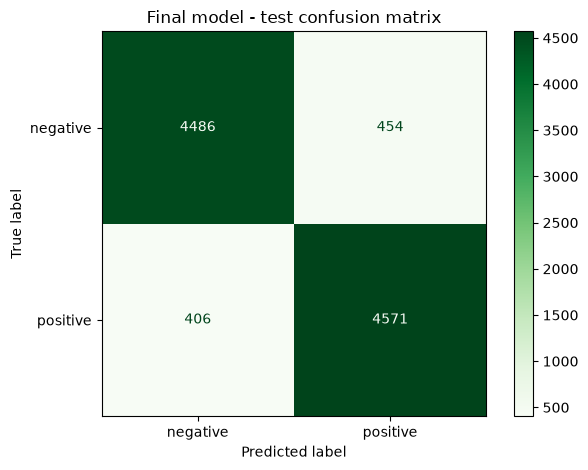

In [102]:
pred = final.predict(Xte)
proba = final.predict_proba(Xte)[:, 1]
acc = accuracy_score(y_test, pred)
p, r, f1, _ = precision_recall_fscore_support(y_test, pred, average="binary")
auc = roc_auc_score(y_test, proba)
print(f"Accuracy={acc:.4f} Precision={p:.4f} Recall={r:.4f} F1={f1:.4f} ROC-AUC={auc:.4f}")
print(classification_report(y_test, pred, target_names=["negative", "positive"]))
ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=["negative", "positive"], cmap="Greens")
plt.title("Final model - test confusion matrix"); plt.tight_layout()
plt.show()

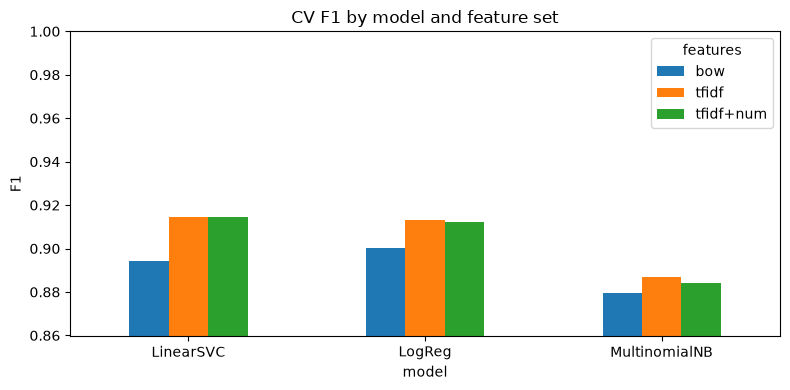

In [103]:
ax = results.pivot(index="model", columns="features", values="cv_f1").plot.bar(figsize=(8, 4), rot=0)
ax.set(title="CV F1 by model and feature set", ylabel="F1", ylim=(results["cv_f1"].min() - 0.02, 1))
plt.tight_layout(); plt.show()

In [104]:
joblib.dump(final, f"{OUT_DIR}/final_model.joblib")
joblib.dump({"model": best["model"], "features": best["features"], "params": gs.best_params_,
             "uses_numeric": best["features"] == "tfidf+num",
             "test_metrics": {"accuracy": acc, "precision": p, "recall": r, "f1": f1, "roc_auc": auc}},
            f"{OUT_DIR}/final_model_info.joblib")
print(f"Saved final_model.joblib and final_model_info.joblib to ./{OUT_DIR}/")

Saved final_model.joblib and final_model_info.joblib to ./artifacts/
